In [ ]:
#|default_exp sgd

# Accelerated SGD

In [1]:
#|export
import torch

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *

/Users/bytedance/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *

In [3]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)

import logging
logging.disable(logging.WARNING)

set_seed(42)

In [4]:
xl,yl = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

bs = 1024
xmean,xstd = 0.28, 0.35

@inplace
def transformi(b): b[xl] = [(TF.to_tensor(o)-xmean)/xstd for o in b[xl]]

tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

In [5]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
astats = ActivationStats(fc.risinstance(GeneralRelu))
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
lrf_cbs = [DeviceCB(), LRFinderCB()]

## Optimizers

### SGD

In [21]:
class SGD:
    def __init__(self, params, lr, wd=0.):
        params = list(params)
        fc.store_attr()
        self.i = 0

    def step(self):
        with torch.no_grad():
            for p in self.params:
                self.reg_step(p)
                self.opt_step(p)
        self.i +=1

    def opt_step(self, p): p -= p.grad * self.lr
    def reg_step(self, p):
        if self.wd != 0: p *= 1 - self.lr*self.wd

    def zero_grad(self):
        for p in self.params: p.grad.data.zero_()

In [22]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=0.4, cbs=cbs, opt_func=SGD)

accuracy,loss,epoch,train
0.762,0.677,0,train
0.819,0.495,0,eval
0.839,0.440,1,train
0.842,0.433,1,eval
0.859,0.386,2,train
0.847,0.417,2,eval


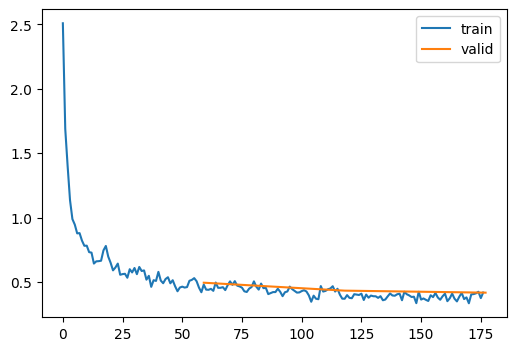

In [23]:
learn.fit(3)

Consider the difference between *weight decay* and *L2 regularization*:

``` python
weight -= lr*wd*weight
```

...vs...

``` python
weight.grad += wd*weight
```

### Momentum

In [24]:
xs = torch.linspace(-4, 4, 100)
ys = 1 - (xs/3) ** 2 + torch.randn(100) * 0.1

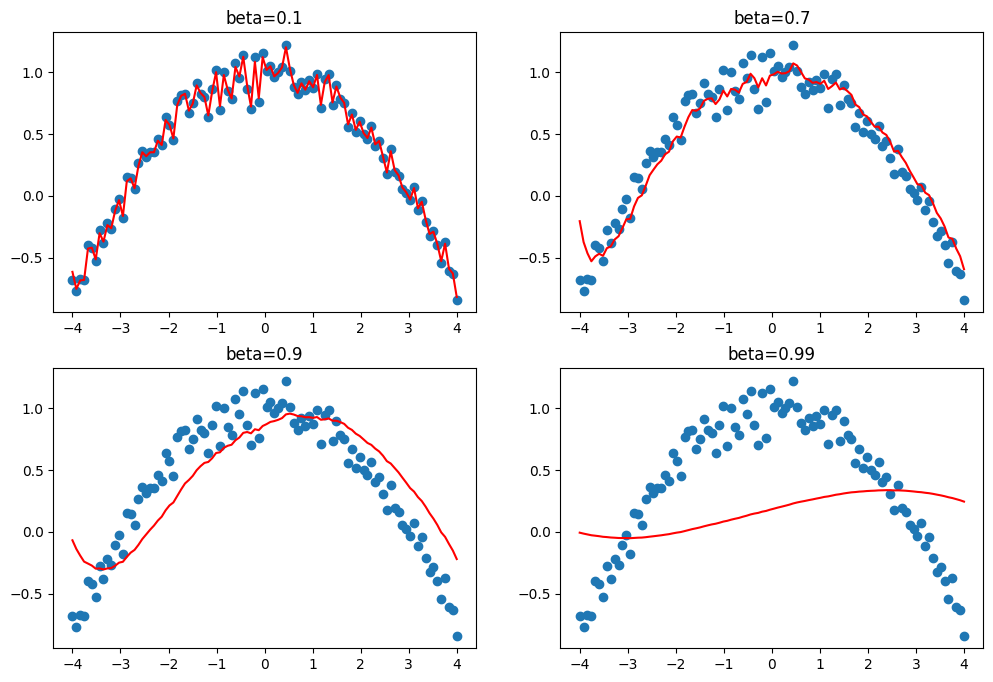

In [25]:
_,axs = plt.subplots(2,2, figsize=(12,8))
betas = [0.1,0.7,0.9,0.99]
for beta,ax in zip(betas, axs.flatten()):
    ax.scatter(xs,ys)
    avg,res = 0,[]
    for yi in ys:
        avg = beta*avg + (1-beta)*yi
        res.append(avg)
    ax.plot(xs,np.array(res), color='red');
    ax.set_title(f'beta={beta}')

In [26]:
class Momentum(SGD):
    def __init__(self, params, lr, wd=0., mom=0.9):
        super().__init__(params, lr=lr, wd=wd)
        self.mom=mom

    def opt_step(self, p):
        if not hasattr(p, 'grad_avg'): p.grad_avg = torch.zeros_like(p.grad)
        p.grad_avg = p.grad_avg*self.mom + p.grad*(1-self.mom)
        p -= self.lr * p.grad_avg

In [27]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=1.5, cbs=cbs, opt_func=Momentum)

accuracy,loss,epoch,train
0.775,0.627,0,train
0.844,0.437,0,eval
0.868,0.366,1,train
0.866,0.368,1,eval
0.880,0.327,2,train
0.868,0.348,2,eval


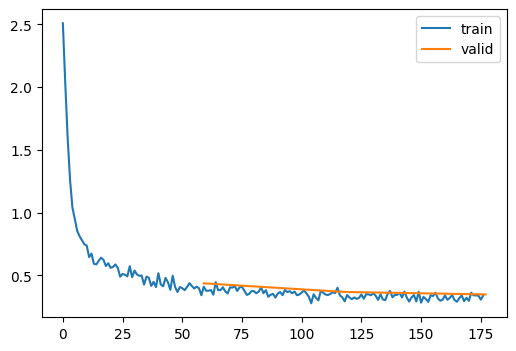

In [28]:
learn.fit(3)

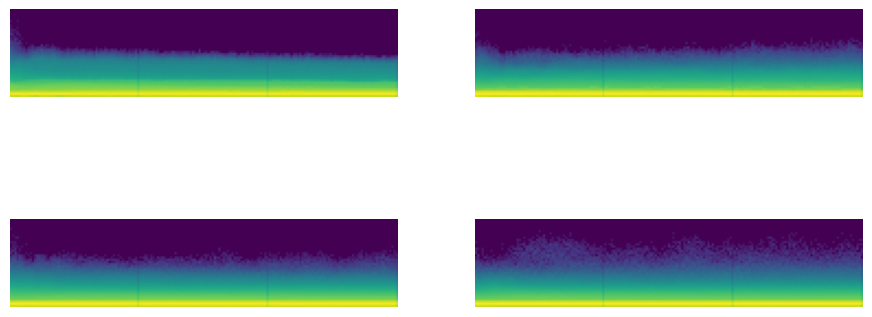

In [29]:
astats.color_dim()

### RMSProp

In [30]:
class RMSProp(SGD):
    def __init__(self, params, lr, wd=0., sqr_mom=0.99, eps=1e-5):
        super().__init__(params, lr=lr, wd=wd)
        self.sqr_mom,self.eps = sqr_mom,eps

    def opt_step(self, p):
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = p.grad**2
        p.sqr_avg = p.sqr_avg*self.sqr_mom + p.grad**2*(1-self.sqr_mom)
        p -= self.lr * p.grad/(p.sqr_avg.sqrt() + self.eps)

accuracy,loss,epoch,train
0.762,0.677,0,train
0.818,0.489,0,eval
0.848,0.419,1,train
0.844,0.432,1,eval
0.865,0.366,2,train
0.856,0.395,2,eval


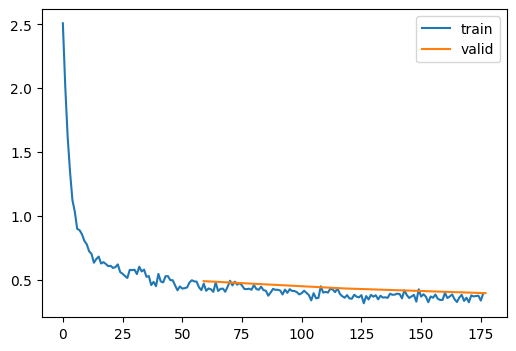

In [31]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=3e-3, cbs=cbs, opt_func=RMSProp)
learn.fit(3)

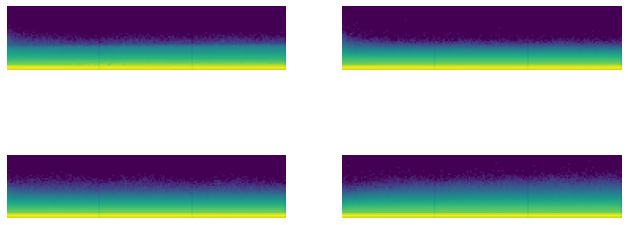

In [ ]:
astats.color_dim()

### Adam 优化器（自适应矩估计 Adaptive Moment Estimation）

**Adam = Momentum（动量）+ RMSProp 的结合体**

| 组件 | 作用 | 类比 |
|---|---|---|
| **beta1（一阶矩）** | 记住梯度的"方向"，平滑更新 | 球在山坡上的**惯性** |
| **beta2（二阶矩）** | 记住梯度的"大小"，自适应步长 | 对地形**坡度**的记忆 |
| **偏差修正** | 修正初始阶段的估计偏差 | 刚出发时的"校准" |

**核心公式：**
$$\theta_{t} = \theta_{t-1} - \frac{lr \cdot \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

- $\hat{m}_t$：校正后的梯度均值（告诉我们往**哪个方向**走）  
- $\hat{v}_t$：校正后的梯度方差（告诉我们每个方向走**多大步**）

In [ ]:
class Adam(SGD):
    """
    Adam 优化器（自适应矩估计）
    
    相比普通 SGD，Adam 有两大改进：
    1. 【方向平滑】用梯度的移动平均代替原始梯度（= Momentum）
    2. 【步长自适应】根据每个参数历史梯度大小，自动调整步长（= RMSProp）
    
    参数说明：
        params : 模型所有需要训练的参数
        lr     : 学习率，控制整体更新幅度
        wd     : 权重衰减（Weight Decay），防止过拟合
        beta1  : 一阶矩衰减系数，默认0.9（梯度方向的"记忆长度"）
        beta2  : 二阶矩衰减系数，默认0.99（梯度大小的"记忆长度"）
        eps    : 极小值，防止分母为零（约等于 0.00001）
    """
    def __init__(self, params, lr, wd=0., beta1=0.9, beta2=0.99, eps=1e-5):
        super().__init__(params, lr=lr, wd=wd)
        self.beta1 = beta1   # 控制"方向记忆"强度：0.9 意味着保留 90% 旧方向 + 10% 新梯度
        self.beta2 = beta2   # 控制"大小记忆"强度：0.99 意味着保留 99% 旧信息 + 1% 新梯度²
        self.eps   = eps     # 防止除以零的安全值

    def opt_step(self, p):
        # ── 第 0 步：首次运行时，初始化两个"记忆"为全零 ─────────────────────────
        # p.avg     : 一阶矩（梯度的移动均值），记录梯度的方向
        # p.sqr_avg : 二阶矩（梯度平方的移动均值），记录梯度的大小
        if not hasattr(p, 'avg'):     p.avg     = torch.zeros_like(p.grad.data)
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = torch.zeros_like(p.grad.data)

        # ── 第 1 步：更新一阶矩（梯度方向的指数移动平均 = Momentum）─────────────
        # 公式：m_t = β1 * m_{t-1} + (1 - β1) * g_t
        #
        # 直觉理解：
        #   新的"方向记忆" = 旧记忆的90% + 当前梯度的10%
        #   就像球滚下坡时有惯性，不会因一次小扰动就猛然转向
        #
        # 举例：
        #   若连续3步梯度都是 [+1.0]，则：
        #   t=1: avg = 0.9*0 + 0.1*1 = 0.1
        #   t=2: avg = 0.9*0.1 + 0.1*1 = 0.19
        #   t=3: avg = 0.9*0.19 + 0.1*1 = 0.271  （越来越接近真实梯度1.0）
        p.avg = self.beta1 * p.avg + (1 - self.beta1) * p.grad

        # ── 第 2 步：偏差修正一阶矩 ────────────────────────────────────────────
        # 问题：初始 p.avg=0，导致前几步 avg 远小于真实梯度（偏向0的"冷启动"问题）
        #
        # 修正公式：m̂_t = m_t / (1 - β1^t)
        #   其中 t = self.i + 1（当前是第几步）
        #
        # 数字示例（β1=0.9）：
        #   t=1 时，除以 (1 - 0.9^1) = 0.1，相当于乘以10，将低估值放大补偿
        #   t=2 时，除以 (1 - 0.9^2) = 0.19，乘以 ~5.3，补偿逐渐减少
        #   t=10时，除以 (1 - 0.9^10) ≈ 0.65，乘以 ~1.5，补偿已很小
        #   t→∞ 时，分母→1，修正几乎不起作用（已经收敛）
        unbias_avg = p.avg / (1 - (self.beta1 ** (self.i + 1)))

        # ── 第 3 步：更新二阶矩（梯度平方的移动平均 = RMSProp）─────────────────
        # 公式：v_t = β2 * v_{t-1} + (1 - β2) * g_t²
        #
        # 直觉理解：
        #   记录"这个参数的梯度通常有多大"
        #   → 若某参数梯度一直很大（坡很陡），sqr_avg 会大，之后步长自动缩小（谨慎）
        #   → 若某参数梯度一直很小（坡很平），sqr_avg 会小，之后步长自动放大（激进）
        #
        # 这就是"自适应"的含义：每个参数有自己专属的有效学习率
        p.sqr_avg = self.beta2 * p.sqr_avg + (1 - self.beta2) * (p.grad ** 2)

        # ── 第 4 步：偏差修正二阶矩 ────────────────────────────────────────────
        # 同第 2 步的原理，修正初始阶段 sqr_avg 偏小的问题
        unbias_sqr_avg = p.sqr_avg / (1 - (self.beta2 ** (self.i + 1)))

        # ── 第 5 步：计算实际更新量并更新参数 ──────────────────────────────────
        # 公式：θ_t = θ_{t-1} - lr * m̂_t / (√v̂_t + ε)
        #
        # 分子 unbias_avg     ：带有方向和平滑信息的梯度估计
        # 分母 √unbias_sqr_avg：根据历史梯度大小缩放步长
        # eps                 ：防止 v̂_t=0 时除以零（数值稳定性）
        #
        # 整体效果：
        #   每个参数的"有效学习率" = lr / √v̂_t
        #   历史梯度大 → 有效学习率小；历史梯度小 → 有效学习率大
        p -= self.lr * unbias_avg / (unbias_sqr_avg + self.eps).sqrt()


class AdamDebug(Adam):
    """
    带调试打印的 Adam 优化器（仅用于学习理解，不用于实际训练）
    
    用法：
        learn = TrainLearner(model, dls, F.cross_entropy, lr=6e-3,
                             cbs=debug_cbs, opt_func=AdamDebug)
        learn.fit(1)  # 只跑1轮，否则打印太多
    """
    def __init__(self, params, lr, wd=0., beta1=0.9, beta2=0.99, eps=1e-5, print_steps=3):
        super().__init__(params, lr=lr, wd=wd, beta1=beta1, beta2=beta2, eps=eps)
        self.print_steps = print_steps
        # 用集合记录"已经打印过哪些步骤编号"
        # 原因：self.i 在一个 step() 内遍历所有参数期间保持不变，
        #       所以每个新的 self.i 值只需打印一次（取第一个参数的数值展示即可）
        self._printed_steps = set()

    def opt_step(self, p):
        # 判断本步是否需要打印：
        #   1. 还没超过 print_steps 限制
        #   2. 本步（self.i）尚未打印过（同一步内有多个参数，只打印第一个）
        should_print = (self.i < self.print_steps) and (self.i not in self._printed_steps)

        # 先初始化（首次）
        if not hasattr(p, 'avg'):     p.avg     = torch.zeros_like(p.grad.data)
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = torch.zeros_like(p.grad.data)

        # 更新一阶矩
        p.avg = self.beta1 * p.avg + (1 - self.beta1) * p.grad
        # 之所以要做unbias，是因为起始p.avg = 0，导致前几步 avg 远小于真实梯度（偏向0的"冷启动"问题）
        unbias_avg = p.avg / (1 - (self.beta1 ** (self.i + 1)))

        # 更新二阶矩
        p.sqr_avg = self.beta2 * p.sqr_avg + (1 - self.beta2) * (p.grad ** 2)
        unbias_sqr_avg = p.sqr_avg / (1 - (self.beta2 ** (self.i + 1)))

        # 计算自适应有效学习率（每个参数不同）
        effective_lr = self.lr / (unbias_sqr_avg + self.eps).sqrt()

        if should_print:
            # 只取第一个元素展示，避免输出太长
            g   = p.grad.flatten()[0].item()
            m   = unbias_avg.flatten()[0].item()
            v   = unbias_sqr_avg.flatten()[0].item()
            eff = effective_lr.flatten()[0].item()
            upd = (self.lr * unbias_avg / (unbias_sqr_avg + self.eps).sqrt()).flatten()[0].item()

            print(f"\n{'='*55}")
            print(f"  Adam 调试 | 全局步骤 t = {self.i + 1}")
            print(f"{'='*55}")
            print(f"  超参数    : lr={self.lr}, β1={self.beta1}, β2={self.beta2}")
            print(f"  偏差修正系数: 1-β1^t = {1 - self.beta1**(self.i+1):.4f}  |  "
                  f"1-β2^t = {1 - self.beta2**(self.i+1):.4f}")
            print(f"  {'参数':<12} {'值':>12}  {'含义'}")
            print(f"  {'─'*50}")
            print(f"  {'g (梯度)':<12} {g:>12.6f}  当前这步的原始梯度")
            print(f"  {'m̂ (一阶矩)':<12} {m:>12.6f}  修正后的梯度均值（方向）")
            print(f"  {'v̂ (二阶矩)':<12} {v:>12.6f}  修正后的梯度方差（大小²）")
            print(f"  {'√v̂ (RMS)':<12} {v**0.5:>12.6f}  梯度均方根（自适应缩放）")
            print(f"  {'有效lr':<12} {eff:>12.6f}  = lr / √v̂  (自适应学习率)")
            print(f"  {'实际更新量':<12} {upd:>12.6f}  = lr * m̂ / (√v̂ + ε)")
            print(f"  → 参数沿梯度反方向移动 {abs(upd):.6f}")

            # 把本步编号加入已打印集合，同一步内其他参数不再重复打印
            self._printed_steps.add(self.i)

        # 真正更新参数
        p -= self.lr * unbias_avg / (unbias_sqr_avg + self.eps).sqrt()

accuracy,loss,epoch,train
0.782,0.612,0,train
0.842,0.437,0,eval
0.866,0.368,1,train
0.866,0.373,1,eval
0.882,0.321,2,train
0.868,0.356,2,eval


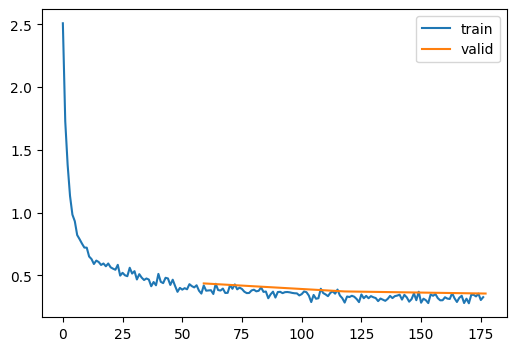

In [33]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=6e-3, cbs=cbs, opt_func=Adam)
learn.fit(3)

#### 用 AdamDebug 观察前 3 步的内部计算过程

运行下面的 cell 可以看到每个 optimizer step 里面各个中间量的实际数值，帮助理解公式。

In [37]:
# 使用 AdamDebug 观察前3步的中间量（只跑1轮，避免刷屏）
# 注意：ProgressCB 的进度条可能会和 print 输出混排，这是正常的
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
# 去掉 ProgressCB，让打印输出更清晰
debug_cbs = [DeviceCB(), metrics]
learn_debug = TrainLearner(model, dls, F.cross_entropy, lr=6e-3, cbs=debug_cbs, opt_func=AdamDebug)
learn_debug.fit(1)


  Adam 调试 | 全局步骤 t = 1
  超参数    : lr=0.006, β1=0.9, β2=0.99
  偏差修正系数: 1-β1^t = 0.1000  |  1-β2^t = 0.0100
  参数                      值  含义
  ──────────────────────────────────────────────────
  g (梯度)          -0.003958  当前这步的原始梯度
  m̂ (一阶矩)        -0.003958  修正后的梯度均值（方向）
  v̂ (二阶矩)         0.000016  修正后的梯度方差（大小²）
  √v̂ (RMS)        0.003958  梯度均方根（自适应缩放）
  有效lr             1.184253  = lr / √v̂  (自适应学习率)
  实际更新量           -0.004688  = lr * m̂ / (√v̂ + ε)
  → 参数沿梯度反方向移动 0.004688

  Adam 调试 | 全局步骤 t = 2
  超参数    : lr=0.006, β1=0.9, β2=0.99
  偏差修正系数: 1-β1^t = 0.1900  |  1-β2^t = 0.0199
  参数                      值  含义
  ──────────────────────────────────────────────────
  g (梯度)           0.021197  当前这步的原始梯度
  m̂ (一阶矩)         0.009281  修正后的梯度均值（方向）
  v̂ (二阶矩)         0.000234  修正后的梯度方差（大小²）
  √v̂ (RMS)        0.015284  梯度均方根（自适应缩放）
  有效lr             0.384437  = lr / √v̂  (自适应学习率)
  实际更新量            0.003568  = lr * m̂ / (√v̂ + ε)
  → 参数沿梯度反方向移动 0.003568

  Adam 调试 | 全局步骤 t = 3
  超参数    :

## Schedulers

We've already seen how we can easily write a custom LR-adjusting callback or `Learner`, or can use the predefined PyTorch schedulers. We'll use the predefined ones for now since there's nothing new to learn in implementing them ourselves.

In [ ]:
' '.join(o for o in dir(lr_scheduler) if o[0].isupper() and o[1].islower())

'ChainedScheduler ConstantLR CosineAnnealingLR CosineAnnealingWarmRestarts Counter CyclicLR ExponentialLR LambdaLR LinearLR MultiStepLR MultiplicativeLR OneCycleLR Optimizer PolynomialLR ReduceLROnPlateau SequentialLR StepLR'

In [ ]:
' '.join(filter(lambda x: x[0].isupper() and x[1].islower(), dir(lr_scheduler)))

'ChainedScheduler ConstantLR CosineAnnealingLR CosineAnnealingWarmRestarts Counter CyclicLR ExponentialLR LambdaLR LinearLR MultiStepLR MultiplicativeLR OneCycleLR Optimizer PolynomialLR ReduceLROnPlateau SequentialLR StepLR'

In [ ]:
learn = TrainLearner(get_model(), dls, F.cross_entropy, lr=6e-3, cbs=[DeviceCB(), SingleBatchCB()])
learn.fit(1)

In [ ]:
opt = learn.opt
' '.join(o for o in dir(opt) if o[0]!='_')

'add_param_group defaults load_state_dict param_groups state state_dict step zero_grad'

In [ ]:
opt

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    lr: 0.006
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
param = next(iter(learn.model.parameters()))
st = opt.state[param]

In [ ]:
st

{'momentum_buffer': None}

In [ ]:
len(opt.param_groups)

1

In [ ]:
pg = opt.param_groups[0]

In [ ]:
list(pg)

['params',
 'lr',
 'momentum',
 'dampening',
 'weight_decay',
 'nesterov',
 'maximize',
 'foreach',
 'differentiable']

In [ ]:
sched = lr_scheduler.CosineAnnealingLR(opt, 100)

In [ ]:
sched.base_lrs

[0.006]

In [ ]:
sched.get_last_lr()

[0.006]

In [ ]:
def sched_lrs(sched, steps):
    lrs = [sched.get_last_lr()]
    for i in range(steps):
        sched.optimizer.step()
        sched.step()
        lrs.append(sched.get_last_lr())
    plt.plot(lrs)

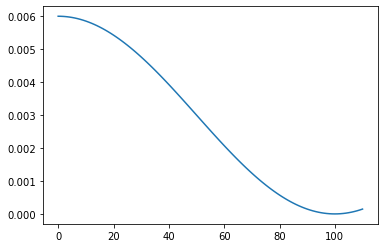

In [ ]:
sched_lrs(sched, 110)

### Scheduler callbacks

In [ ]:
#|export
class BaseSchedCB(Callback):
    def __init__(self, sched): self.sched = sched
    def before_fit(self, learn): self.schedo = self.sched(learn.opt)
    def _step(self, learn):
        if learn.training: self.schedo.step()

In [ ]:
#|export
class BatchSchedCB(BaseSchedCB):
    def after_batch(self, learn): self._step(learn)

In [ ]:
#|export
class HasLearnCB(Callback):
    def before_fit(self, learn): self.learn = learn 
    def after_fit(self, learn): self.learn = None

In [ ]:
#|export
class RecorderCB(Callback):
    def __init__(self, **d): self.d = d
    def before_fit(self, learn):
        self.recs = {k:[] for k in self.d}
        self.pg = learn.opt.param_groups[0]
    
    def after_batch(self, learn):
        if not learn.training: return
        for k,v in self.d.items():
            self.recs[k].append(v(self))

    def plot(self):
        for k,v in self.recs.items():
            plt.plot(v, label=k)
            plt.legend()
            plt.show()

In [ ]:
def _lr(cb): return cb.pg['lr']

In [ ]:
len(dls.train)

59

In [ ]:
tmax = 3 * len(dls.train)
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=tmax)

accuracy,loss,epoch,train
0.809,0.515,0,train
0.858,0.383,0,eval
0.881,0.327,1,train
0.874,0.339,1,eval
0.898,0.280,2,train
0.883,0.317,2,eval


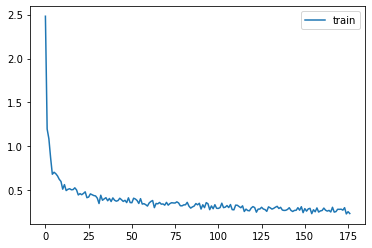

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
rec = RecorderCB(lr=_lr)
xtra = [BatchSchedCB(sched),rec]
learn = TrainLearner(model, dls, F.cross_entropy, lr=2e-2, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(3)

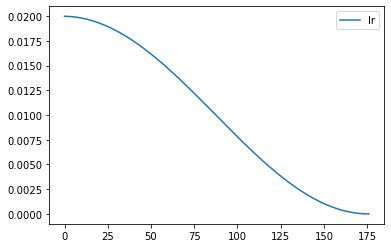

In [ ]:
rec.plot()

In [ ]:
#|export
class EpochSchedCB(BaseSchedCB):
    def after_epoch(self, learn): self._step(learn)

accuracy,loss,epoch,train
0.809,0.517,0,train
0.857,0.382,0,eval
0.881,0.327,1,train
0.875,0.339,1,eval
0.899,0.275,2,train
0.887,0.307,2,eval


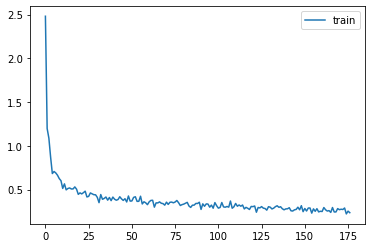

In [ ]:
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=3)
set_seed(42)
xtra = [EpochSchedCB(sched),rec]
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=2e-2, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(3)

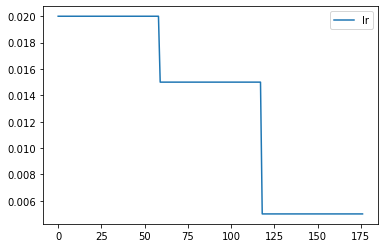

In [ ]:
rec.plot()

### 1cycle training

[Paper](https://arxiv.org/abs/1803.09820) by Leslie Smith.

In [ ]:
def _beta1(cb): return cb.pg['betas'][0]
rec = RecorderCB(lr=_lr, mom=_beta1)

accuracy,loss,epoch,train
0.765,0.662,0,train
0.822,0.546,0,eval
0.862,0.376,1,train
0.856,0.413,1,eval
0.888,0.304,2,train
0.879,0.333,2,eval
0.904,0.257,3,train
0.901,0.279,3,eval
0.924,0.210,4,train
0.906,0.267,4,eval


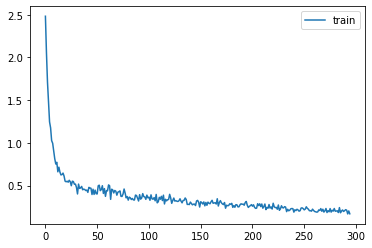

In [ ]:
set_seed(42)
lr,epochs = 6e-2,5
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched), rec]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(epochs)

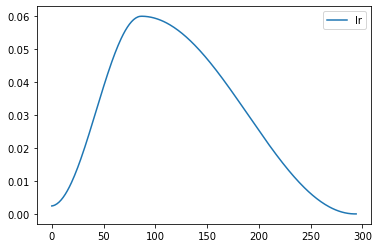

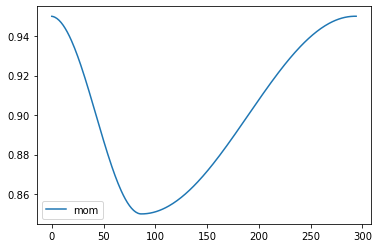

In [ ]:
rec.plot()

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()